# NeuroFEM tutorial

Brad Aimone 

Canadian Neuromorphic Engineering Workshop

June 2026

## Step 0: Download NeuroFEM Paper Notebook

https://github.com/sandialabs/NeuroFEM/blob/main/NeuroFEM_tutorial.ipynb

Also, it would be good to open up the paper, especially the supplemental material

https://www.nature.com/articles/s42256-025-01143-2

Supplemental material:

https://static-content.springer.com/esm/art%3A10.1038%2Fs42256-025-01143-2/MediaObjects/42256_2025_1143_MOESM1_ESM.pdf





## Goal: We want to directly model physics using spiking networks *without learning*

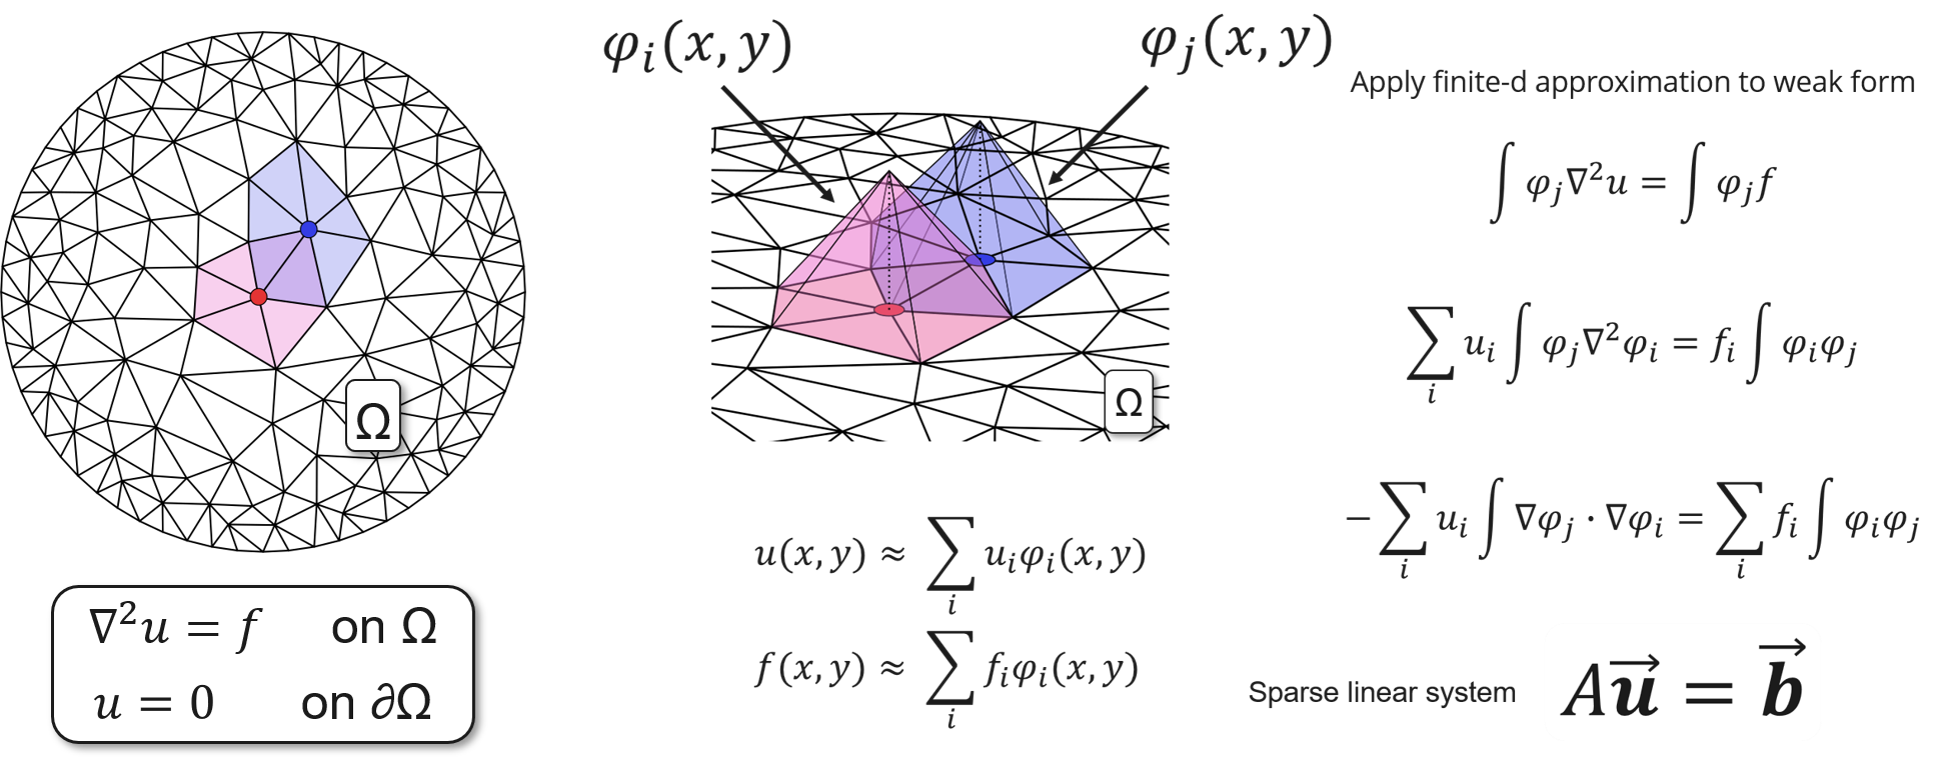

## Outline of NeuroFEM approach

### 1. Define mesh and PDE system matrix 

### 2. Use system matrix to define spiking network connectivity

### 3. Generate readout neurons for each mesh point

## Step 1: Generate mesh

You can generate any mesh here - irregular, 3d, etc.  We start easy for illustration purposes.

The notebook has helper functions for the Poisson equation ($\nabla^2 u = f$), which has broad physics implications (electrostatics, thermodynamics, etc)

$A$ describes how the mesh points interact per the differential equation
$b$ describes the bias onto the physical system

For many physics problems, interactions are local, so $A$ is primarily local, so we are solving a sparse linear system $A x = b$

### Go through Cell 6.  You can see how the conventional SciPy solvers solve this equation.  These are small meshes and easy to solve 


## Step 2: Set up recurrent network

So let's imagine we have a mesh where each meshpoint has a few neurons that are going to dynamically solve for each local solution 'x'  

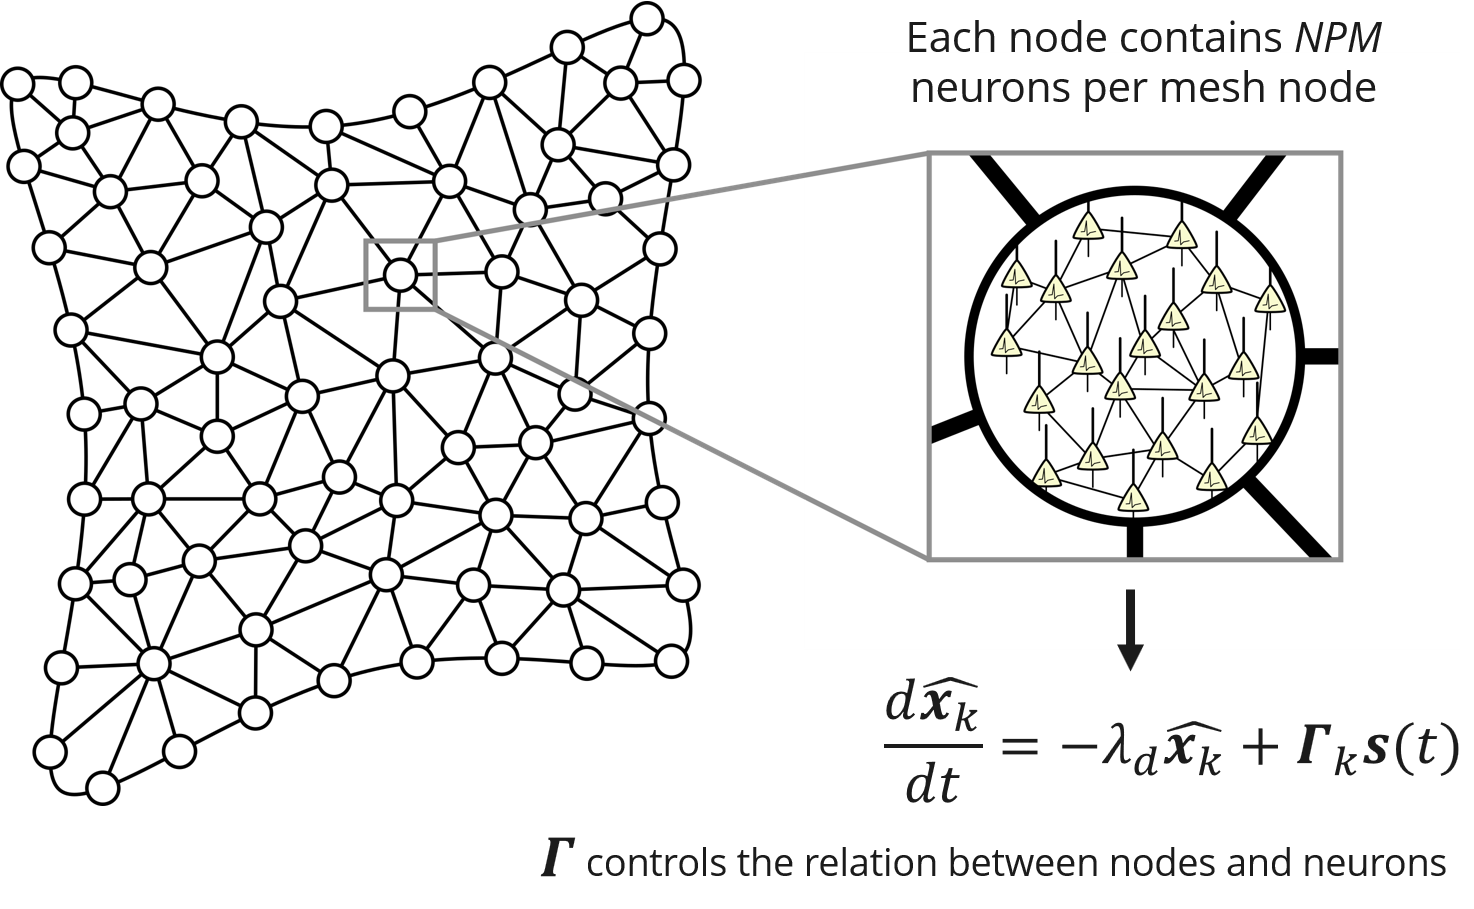

We do this by taking a spiking network approach by Boerlin, Machens, Deneve

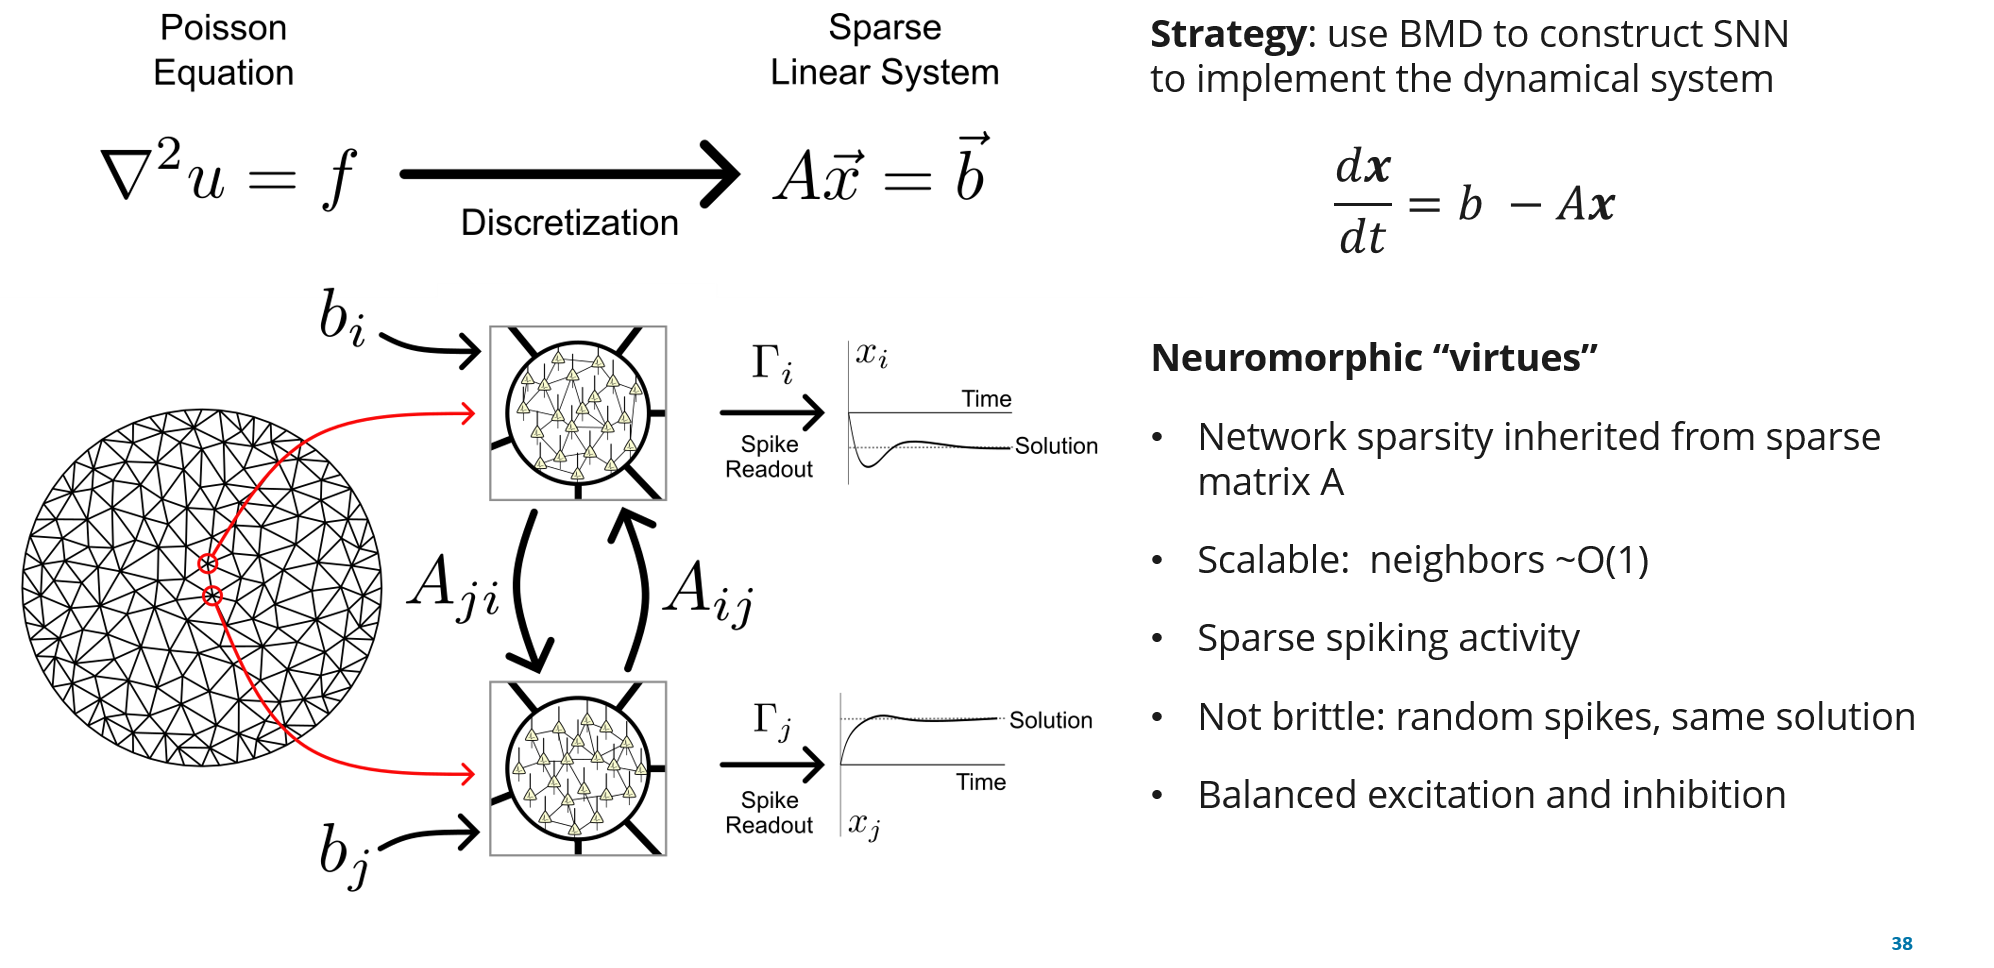

Effectively we are solving this control loop

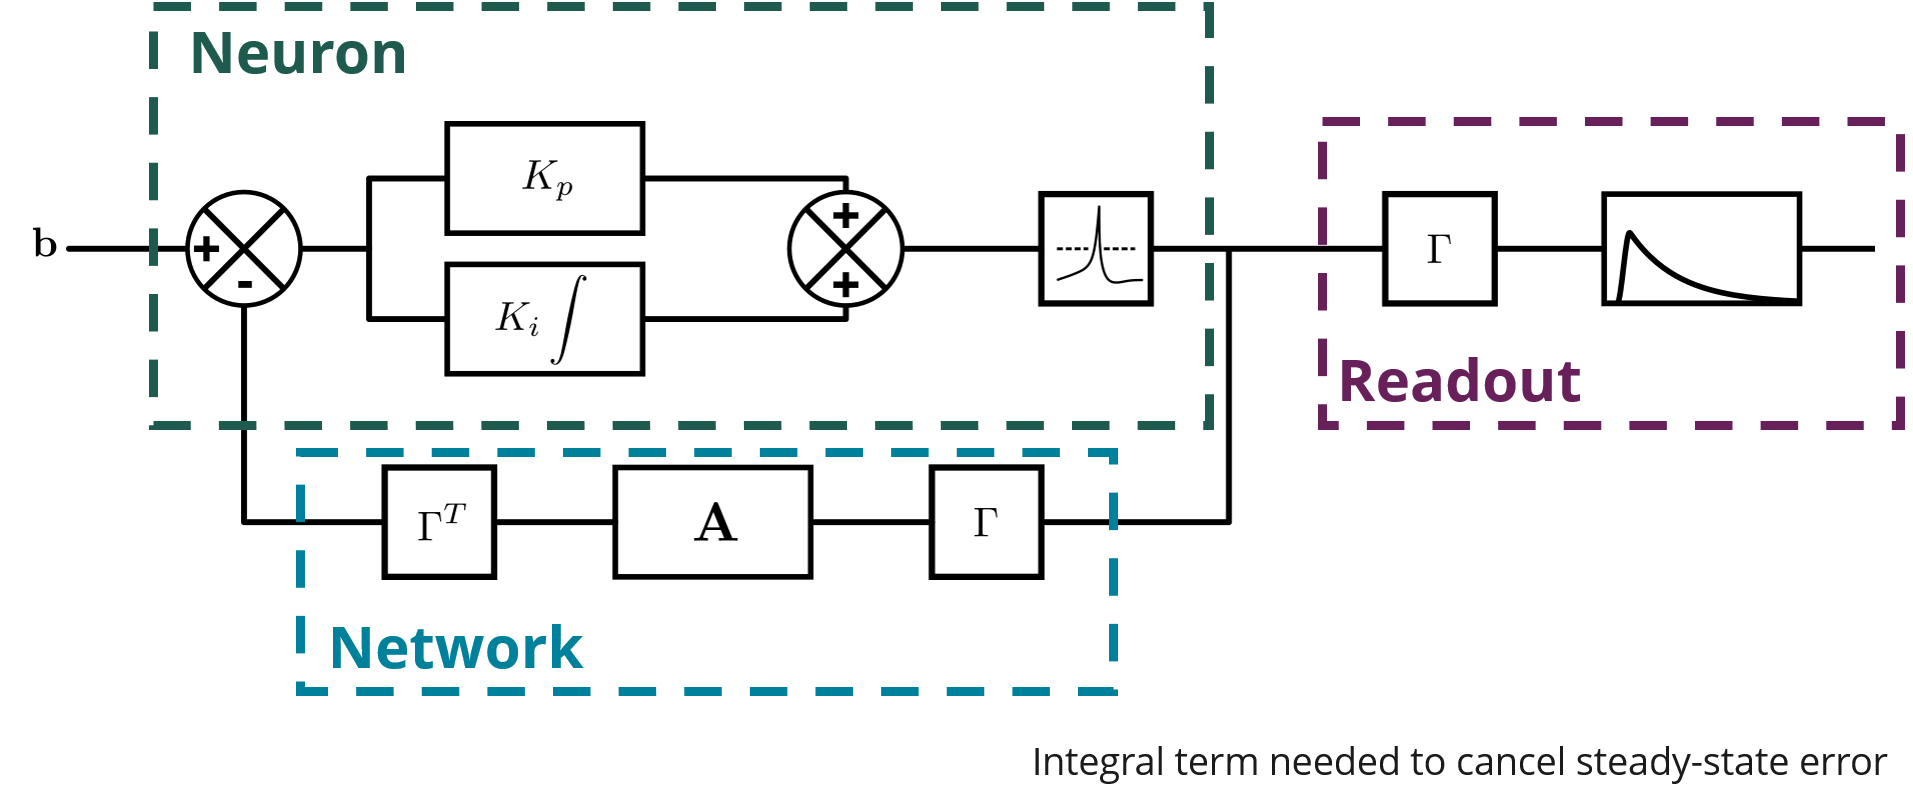

for every neuron.  That derives to the following:

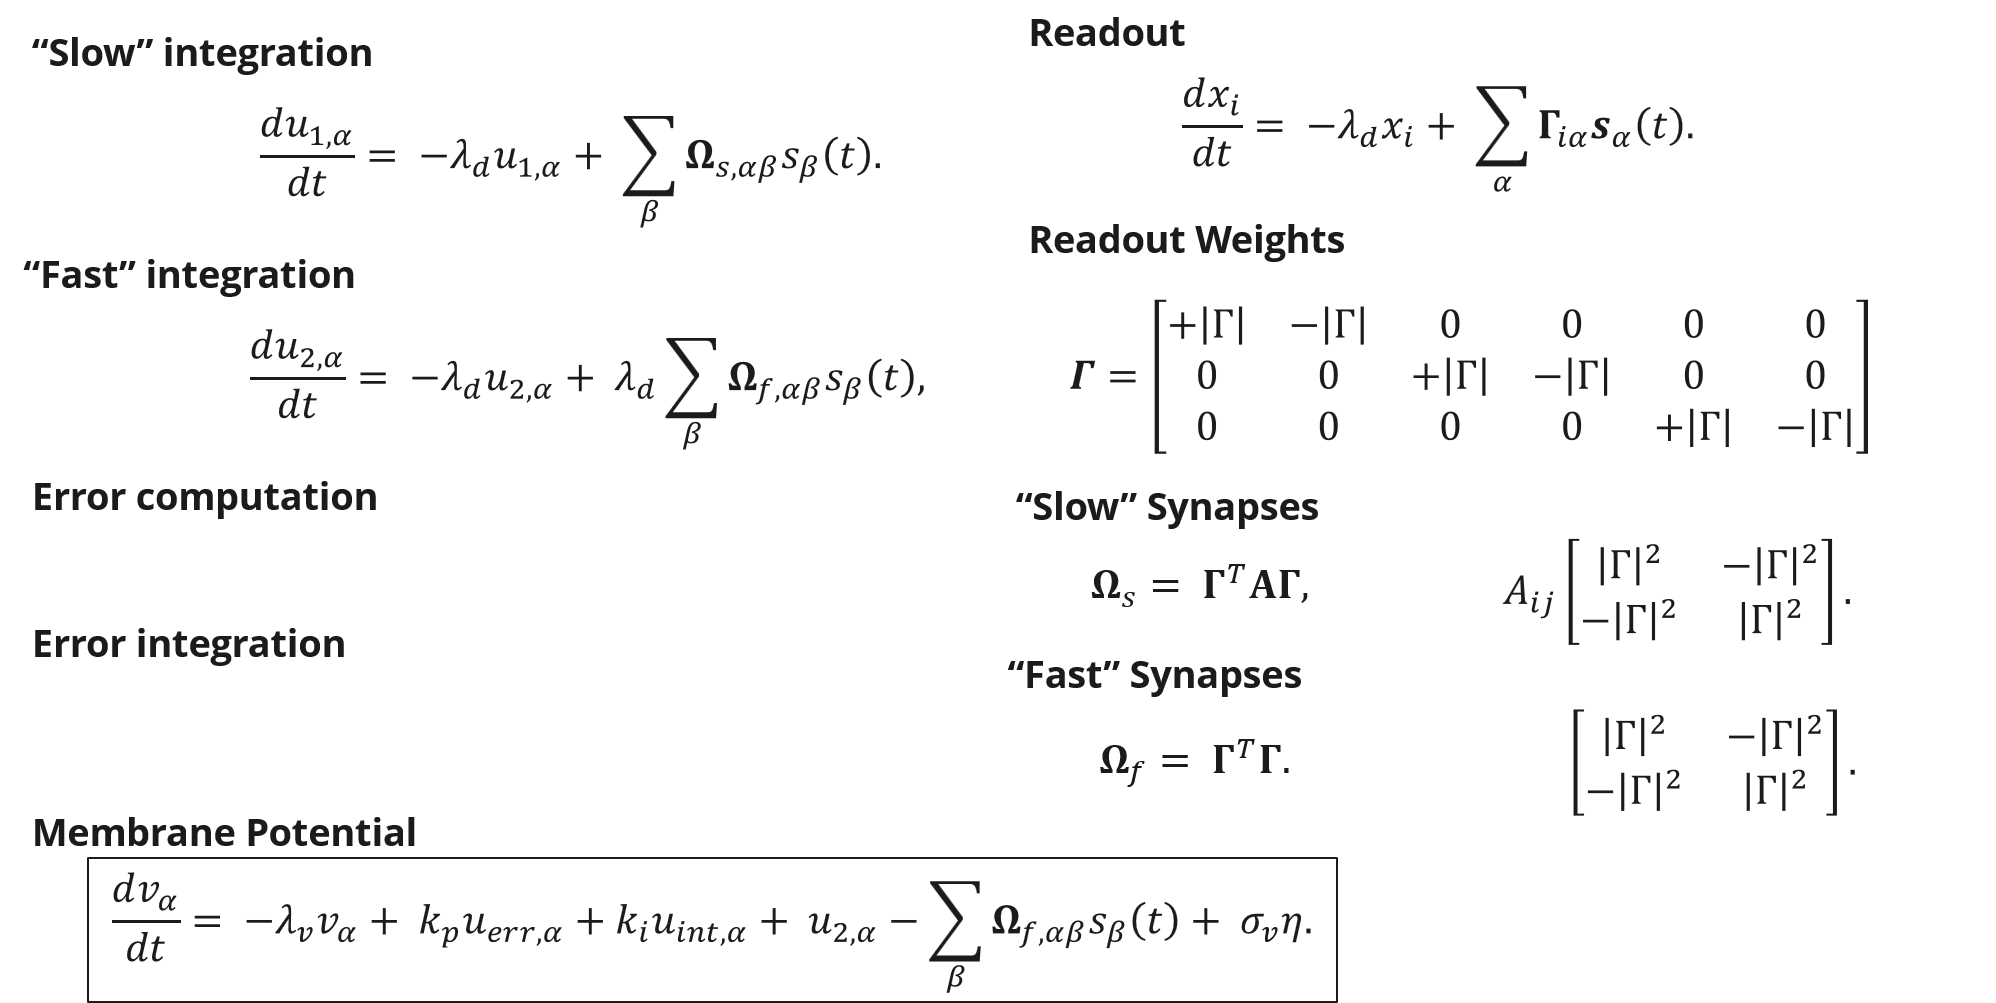

### Cell 3 and Cell 7 implement these equations.  After we go through this, play with some of the parameters in Cell 7 - these affect speed of convergence, accuracy, stability, etc.




## Step 3: Define Outputs

Ultimately, our outputs are just a time-weighted 'push--pull' average of the neurons in each mesh node

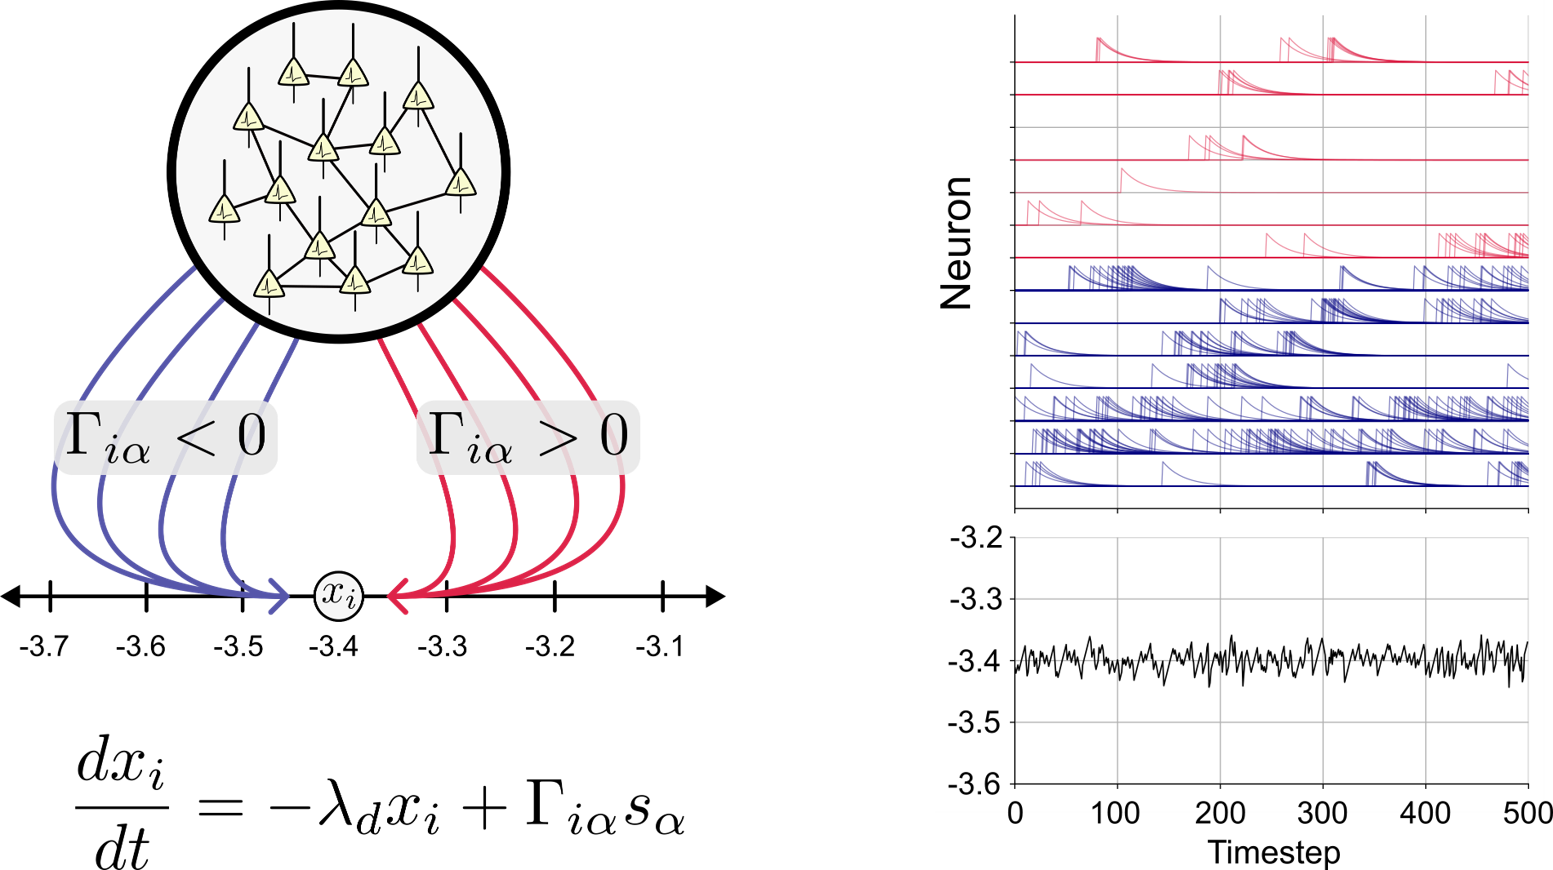

## Step 4: Run the network

For the paper, we directly coded the SNN by hand, as seen in the notebook.  This made mapping these multiple state variables to Loihi more straightforward.  But there is no reason these cannot map to Brian / GeNN - pick your favorite! 

### Click through Cell 9.  The model should run.  Cell 10 computes the relative error (sparse linear systems can directly check the quality of the answer)

## Step 5: Visualize outputs and performance

### Click through the remaining cells for basic visualizations of network performance.

You can see how the network produces qualitatively and quantitatively similar results as the SciPy solver above.  Yet the information moving through are entirely local spikes!

## Step 6: Challenge problems

The notebook is set up for some trial and error

### 1-change the bias vector b.  This does not affect the network at all, but shifts the solution.  It is like putting heat on a different part of the frying pan.

### 2-play with the system matrix A.  This changes the network - the more elements in A, the more connections and slower the network runs.  

Note that much of modern applied mathematics focuses on 'pre-conditioners', which is multiplying a matrix $M^{-1}$ to both the right and left sides of the sparse linear system.  Preconditioners speed up convergence, but make the problem less sparse.

### 3-play with some of the parameters in cell 7.  Changing $\Gamma$ and $\lambda$ will shift convergence speeds, but they're tuned pretty tightly (see paper supplement!) 
